# 05 — Ensemble + SMOTE: Fixing Low Recall
## BCSE209L — Cluster-Adaptive Blood Report Analyzer

**Problem from notebook 04:**
- Precision ≈ 0.95 → when the model flags someone, it's almost always right
- Recall ≈ 0.13 → but it misses 87% of actually abnormal patients

**Why this happens:** Only ~10–20% of patients per label are "positive" (abnormal).
The model learns that predicting "normal" for everyone gives 80%+ accuracy — and coasts.
That's useless medically. Missing a sick patient is far worse than a false alarm.

**What this notebook does:**
- **SMOTE**: creates synthetic "abnormal" training examples so the model stops ignoring them
- **XGBoost `scale_pos_weight`**: mathematically tells the model "mistakes on the minority cost more"
- **AdaBoost**: iteratively puts more weight on the patients the model keeps getting wrong

**Input files:**
- `./data/processed/wide_format.csv`
- `./data/processed/cleaned_with_clusters.csv`


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings, joblib
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              roc_auc_score, hamming_loss)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

os.makedirs("./results/plots",   exist_ok=True)
os.makedirs("./results/metrics", exist_ok=True)
os.makedirs("./results/models",  exist_ok=True)

sns.set_theme(style="whitegrid")
print("Libraries loaded.")


Libraries loaded.


## Step 1 — Load Data (same as notebook 04)

In [2]:
wide  = pd.read_csv("./data/processed/wide_format.csv")
clean = pd.read_csv("./data/processed/cleaned_with_clusters.csv")

wide  = wide.set_index("document_id").loc[clean["document_id"]].reset_index()
wide["cluster"]    = clean["cluster"].values
wide["gender_enc"] = clean["gender_enc"].values

feature_cols = [c for c in clean.columns
                if c not in ["document_id", "gender", "cluster"]]

print(f"Patients : {len(clean):,}")
print(f"Features : {len(feature_cols)}")
print(f"Clusters : {clean['cluster'].value_counts().sort_index().to_dict()}")


Patients : 99,992
Features : 59
Clusters : {0: 34988, 1: 26150, 2: 38854}


## Step 2 — Recreate Cluster-Specific Labels
Identical to notebook 04 — 5th/95th percentile per cluster.
Reproduced here so this notebook runs standalone.


In [3]:
RELEVANT_TESTS = [
    "Hemoglobin", "HbA1c", "Glucose Fasting",
    "TOTAL CHOLESTEROL", "LDL Cholesterol", "Triglycerides", "HDL Cholesterol",
    "SGPT (ALT)", "ASPARTATE AMINOTRANSFERASE (SGOT )",
    "THYROID STIMULATING HORMONE (TSH)",
    "Creatinine", "BLOOD UREA NITROGEN (BUN)"
]

cluster_thresholds = {}
for c in [0, 1, 2]:
    mask = wide["cluster"] == c
    cluster_thresholds[c] = {}
    for test in RELEVANT_TESTS:
        if test not in wide.columns:
            continue
        vals = wide.loc[mask, test].dropna()
        cluster_thresholds[c][test] = {"p05": vals.quantile(0.05),
                                        "p95": vals.quantile(0.95)}

def is_out_of_range(df, test):
    result = pd.Series(False, index=df.index)
    for c in [0, 1, 2]:
        if test not in cluster_thresholds[c]:
            continue
        mask = df["cluster"] == c
        p05  = cluster_thresholds[c][test]["p05"]
        p95  = cluster_thresholds[c][test]["p95"]
        result.loc[mask] = (df.loc[mask, test] < p05) | (df.loc[mask, test] > p95)
    return result.astype(int)

y = pd.DataFrame(index=wide.index)
y["Anaemia"]          = is_out_of_range(wide, "Hemoglobin")
y["Diabetes_Risk"]    = is_out_of_range(wide, "HbA1c")
y["Dyslipidemia"]     = (is_out_of_range(wide, "TOTAL CHOLESTEROL") |
                          is_out_of_range(wide, "LDL Cholesterol")   |
                          is_out_of_range(wide, "Triglycerides")).clip(0, 1)
y["Liver_Stress"]     = (is_out_of_range(wide, "SGPT (ALT)") |
                          is_out_of_range(wide, "ASPARTATE AMINOTRANSFERASE (SGOT )")).clip(0, 1)
y["Thyroid_Abnormal"] = is_out_of_range(wide, "THYROID STIMULATING HORMONE (TSH)")
y["Kidney_Risk"]      = (is_out_of_range(wide, "Creatinine") |
                          is_out_of_range(wide, "BLOOD UREA NITROGEN (BUN)")).clip(0, 1)

LABELS = y.columns.tolist()

print("Label prevalence (% of patients flagged as abnormal):")
for lbl, pct in (y.mean() * 100).round(1).items():
    bar = "█" * int(pct / 2)
    print(f"  {lbl:20s}  {pct:5.1f}%  {bar}")


Label prevalence (% of patients flagged as abnormal):
  Anaemia                 9.0%  ████
  Diabetes_Risk           8.9%  ████
  Dyslipidemia           22.0%  ███████████
  Liver_Stress           15.4%  ███████
  Thyroid_Abnormal        9.9%  ████
  Kidney_Risk            16.8%  ████████


## Step 3 — Holdout Dict & Train/Test Split

In [4]:
HOLDOUT = {
    "Anaemia": [
        "Hemoglobin", "PCV", "RBC Count", "MCH", "MCHC", "MCV",
        "RDW-CV", "RDW-SD"
    ],
    "Diabetes_Risk": [
        "HbA1c", "Glucose Fasting", "Estimated Average Glucose (eAG)"
    ],
    "Dyslipidemia": [
        "TOTAL CHOLESTEROL", "LDL Cholesterol", "HDL Cholesterol",
        "Triglycerides", "VLDL CHOLESTEROL", "Non HDL Cholesterol",
        "TC/ HDL CHOLESTEROL RATIO", "LDL / HDL RATIO"
    ],
    "Liver_Stress": [
        "SGPT (ALT)", "ASPARTATE AMINOTRANSFERASE (SGOT )",
        "GAMMA GLUTAMYL TRANSFERASE (GGT)",
        "Bilirubin Total", "Bilirubin Direct", "Bilirubin Indirect",
        "ALKALINE PHOSPHATASE", "A/G Ratio", "Albumin",
        "Globulin", "Total Protein"
    ],
    "Thyroid_Abnormal": [
        "THYROID STIMULATING HORMONE (TSH)",
        "TOTAL THYROXINE (T4)", "TOTAL TRIIODOTHYRONINE (T3)"
    ],
    "Kidney_Risk": [
        "Creatinine", "BLOOD UREA NITROGEN (BUN)", "Urea",
        "BUN / SR.CREATININE RATIO", "Uric Acid"
    ]
}

# Identical split to notebook 04 — same random_state means same patients
train_idx, test_idx = train_test_split(
    range(len(clean)), test_size=0.2, random_state=42
)

X_full = clean[feature_cols].fillna(0)

print(f"Train : {len(train_idx):,} patients")
print(f"Test  : {len(test_idx):,} patients")
print()
print("Features available per label (after excluding direct markers):")
for lbl, excl in HOLDOUT.items():
    kept = [f for f in feature_cols if f not in excl]
    print(f"  {lbl:20s}: {len(kept):>3} features  (excluded {len(excl)})")


Train : 79,993 patients
Test  : 19,999 patients

Features available per label (after excluding direct markers):
  Anaemia             :  51 features  (excluded 8)
  Diabetes_Risk       :  56 features  (excluded 3)
  Dyslipidemia        :  51 features  (excluded 8)
  Liver_Stress        :  48 features  (excluded 11)
  Thyroid_Abnormal    :  56 features  (excluded 3)
  Kidney_Risk         :  54 features  (excluded 5)


## Step 4 — Helper Functions

In [5]:
def get_train_test(label):
    feats = [f for f in feature_cols if f not in HOLDOUT[label]]
    X_tr  = X_full[feats].iloc[train_idx].values
    X_te  = X_full[feats].iloc[test_idx].values
    y_tr  = y[label].iloc[train_idx].values
    y_te  = y[label].iloc[test_idx].values
    return X_tr, X_te, y_tr, y_te, feats

def score_model(name, label, y_te, y_pred, y_prob=None):
    if y_prob is None:
        y_prob = y_pred.astype(float)
    auc = roc_auc_score(y_te, y_prob) if len(np.unique(y_te)) > 1 else 0.5
    return {
        "label"    : label,
        "model"    : name,
        "precision": round(precision_score(y_te, y_pred, zero_division=0), 4),
        "recall"   : round(recall_score(y_te,    y_pred, zero_division=0), 4),
        "f1"       : round(f1_score(y_te,         y_pred, zero_division=0), 4),
        "auc_roc"  : round(auc, 4),
        "support"  : int(y_te.sum())
    }

def safe_smote(X_tr, y_tr, strategy=0.30):
    """
    Oversample the minority (abnormal) class to `strategy` x majority count.
    Automatically reduces k_neighbors if minority class is very small.
    """
    n_pos = y_tr.sum()
    if n_pos < 2:
        print("    SMOTE skipped — fewer than 2 positive samples")
        return X_tr, y_tr
    k  = min(5, n_pos - 1)
    sm = SMOTE(sampling_strategy=strategy, random_state=42, k_neighbors=k)
    return sm.fit_resample(X_tr, y_tr)

print("Helpers ready.")


Helpers ready.


## Step 5 — Train All Models

5 models per label. Predictions are stored here and **reused in Step 9**
(multi-label metrics) — no redundant retraining.

| Model | Strategy |
|---|---|
| `RF_base` | No fix — replicates notebook 04 so you can see before/after |
| `RF_balanced` | `class_weight='balanced'` — quick, free improvement |
| `XGB_weighted` | `scale_pos_weight` = neg÷pos ratio — XGBoost's built-in fix |
| `XGB_SMOTE` | SMOTE oversampling + XGBoost — **main candidate** |
| `AdaBoost_SMOTE` | SMOTE + AdaBoost — focuses on hard cases |


In [6]:
all_results = []

# Store test-set true labels and predictions for Step 9 (multi-label metrics)
# Shape will be (n_test_patients, n_labels) for each model
joint_preds = {
    "RF_base":        [],
    "RF_balanced":    [],
    "XGB_weighted":   [],
    "XGB_SMOTE":      [],
    "AdaBoost_SMOTE": [],
}
joint_true = []

for label in LABELS:
    X_tr, X_te, y_tr, y_te, feats = get_train_test(label)
    pos_rate = y_tr.mean()
    spw = max(1, int((1 - pos_rate) / pos_rate))  # scale_pos_weight for XGBoost

    print(f"\n{'─'*60}")
    print(f"  {label}  |  {y_tr.sum():,} positives / {len(y_tr):,} train  ({pos_rate:.1%})")
    print(f"{'─'*60}")

    joint_true.append(y_te)

    # ── 1. RF baseline (no imbalance handling) ────────────────────────────
    rf_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_base.fit(X_tr, y_tr)
    pred = rf_base.predict(X_te)
    prob = rf_base.predict_proba(X_te)[:, 1]
    all_results.append(score_model("RF_base", label, y_te, pred, prob))
    joint_preds["RF_base"].append(pred)
    print(f"  RF_base        P={all_results[-1]['precision']:.3f}  "
          f"R={all_results[-1]['recall']:.3f}  F1={all_results[-1]['f1']:.3f}")

    # ── 2. RF with class_weight='balanced' ────────────────────────────────
    rf_bal = RandomForestClassifier(n_estimators=100, class_weight="balanced",
                                     random_state=42, n_jobs=-1)
    rf_bal.fit(X_tr, y_tr)
    pred = rf_bal.predict(X_te)
    prob = rf_bal.predict_proba(X_te)[:, 1]
    all_results.append(score_model("RF_balanced", label, y_te, pred, prob))
    joint_preds["RF_balanced"].append(pred)
    print(f"  RF_balanced    P={all_results[-1]['precision']:.3f}  "
          f"R={all_results[-1]['recall']:.3f}  F1={all_results[-1]['f1']:.3f}")

    # ── 3. XGBoost with scale_pos_weight ─────────────────────────────────
    xgb_w = XGBClassifier(n_estimators=200, scale_pos_weight=spw,
                           learning_rate=0.05, max_depth=5,
                           subsample=0.8, colsample_bytree=0.8,
                           eval_metric="logloss", random_state=42,
                           n_jobs=-1, verbosity=0)
    xgb_w.fit(X_tr, y_tr)
    pred = xgb_w.predict(X_te)
    prob = xgb_w.predict_proba(X_te)[:, 1]
    all_results.append(score_model("XGB_weighted", label, y_te, pred, prob))
    joint_preds["XGB_weighted"].append(pred)
    print(f"  XGB_weighted   P={all_results[-1]['precision']:.3f}  "
          f"R={all_results[-1]['recall']:.3f}  F1={all_results[-1]['f1']:.3f}")

    # ── 4. XGBoost + SMOTE ────────────────────────────────────────────────
    X_sm, y_sm = safe_smote(X_tr, y_tr, strategy=0.30)
    print(f"  After SMOTE  : {len(X_sm):,} rows  ({y_sm.mean():.1%} positive)")

    xgb_s = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=5,
                           subsample=0.8, colsample_bytree=0.8,
                           eval_metric="logloss", random_state=42,
                           n_jobs=-1, verbosity=0)
    xgb_s.fit(X_sm, y_sm)
    pred = xgb_s.predict(X_te)
    prob = xgb_s.predict_proba(X_te)[:, 1]
    all_results.append(score_model("XGB_SMOTE", label, y_te, pred, prob))
    joint_preds["XGB_SMOTE"].append(pred)
    print(f"  XGB_SMOTE      P={all_results[-1]['precision']:.3f}  "
          f"R={all_results[-1]['recall']:.3f}  F1={all_results[-1]['f1']:.3f}")

    # ── 5. AdaBoost + SMOTE ───────────────────────────────────────────────
    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3),
        n_estimators=100, learning_rate=0.5, random_state=42
    )
    ada.fit(X_sm, y_sm)
    pred = ada.predict(X_te)
    prob = ada.predict_proba(X_te)[:, 1]
    all_results.append(score_model("AdaBoost_SMOTE", label, y_te, pred, prob))
    joint_preds["AdaBoost_SMOTE"].append(pred)
    print(f"  AdaBoost_SMOTE P={all_results[-1]['precision']:.3f}  "
          f"R={all_results[-1]['recall']:.3f}  F1={all_results[-1]['f1']:.3f}")

    label_rows = [x for x in all_results if x["label"] == label]
    best = max(label_rows, key=lambda x: x["f1"])
    print(f"  ★ Best: {best['model']}  (F1={best['f1']:.3f}  R={best['recall']:.3f})")

# Convert to numpy arrays for multi-label metrics in Step 9
Y_true_mat = np.column_stack(joint_true)
Y_pred_mat = {m: np.column_stack(joint_preds[m]) for m in joint_preds}

print("\n✓ All models trained. Predictions cached for Step 9.")



────────────────────────────────────────────────────────────
  Anaemia  |  7,285 positives / 79,993 train  (9.1%)
────────────────────────────────────────────────────────────
  RF_base        P=0.949  R=0.132  F1=0.231
  RF_balanced    P=0.977  R=0.126  F1=0.223
  XGB_weighted   P=0.200  R=0.461  F1=0.279
  After SMOTE  : 94,520 rows  (23.1% positive)
  XGB_SMOTE      P=0.443  R=0.023  F1=0.044
  AdaBoost_SMOTE P=0.240  R=0.029  F1=0.052
  ★ Best: XGB_weighted  (F1=0.279  R=0.461)

────────────────────────────────────────────────────────────
  Diabetes_Risk  |  7,157 positives / 79,993 train  (8.9%)
────────────────────────────────────────────────────────────
  RF_base        P=0.940  R=0.125  F1=0.220
  RF_balanced    P=0.949  R=0.126  F1=0.222
  XGB_weighted   P=0.189  R=0.565  F1=0.283
  After SMOTE  : 94,686 rows  (23.1% positive)
  XGB_SMOTE      P=0.301  R=0.023  F1=0.043
  AdaBoost_SMOTE P=0.210  R=0.058  F1=0.091
  ★ Best: XGB_weighted  (F1=0.283  R=0.565)

───────────────────

## Step 6 — Results Table

In [7]:
results_df = pd.DataFrame(all_results)
col_order  = ["RF_base", "RF_balanced", "XGB_weighted", "XGB_SMOTE", "AdaBoost_SMOTE"]

print("=== F1 Score per Label ===")
pivot_f1 = results_df.pivot(index="label", columns="model", values="f1")[col_order].round(3)
pivot_f1["Best"] = pivot_f1.max(axis=1)
print(pivot_f1.to_string())

print()
print("=== Recall per Label (the number we are fixing) ===")
pivot_r = results_df.pivot(index="label", columns="model", values="recall")[col_order].round(3)
print(pivot_r.to_string())

print()
print("=== Average across all labels ===")
avg = results_df.groupby("model")[["precision","recall","f1","auc_roc"]].mean().round(3)
print(avg.loc[col_order].to_string())


=== F1 Score per Label ===
model             RF_base  RF_balanced  XGB_weighted  XGB_SMOTE  AdaBoost_SMOTE   Best
label                                                                                 
Anaemia             0.231        0.223         0.279      0.044           0.052  0.279
Diabetes_Risk       0.220        0.222         0.283      0.043           0.091  0.283
Dyslipidemia        0.242        0.232         0.326      0.038           0.014  0.326
Kidney_Risk         0.275        0.265         0.379      0.108           0.108  0.379
Liver_Stress        0.251        0.244         0.317      0.019           0.025  0.317
Thyroid_Abnormal    0.251        0.250         0.221      0.006           0.014  0.251

=== Recall per Label (the number we are fixing) ===
model             RF_base  RF_balanced  XGB_weighted  XGB_SMOTE  AdaBoost_SMOTE
label                                                                          
Anaemia             0.132        0.126         0.460      0.023 

## Step 7 — Before vs After: The Key Result

In [8]:
before = results_df[results_df["model"] == "RF_base"][["label","recall","f1"]].copy()
after  = results_df[results_df["model"] == "XGB_SMOTE"][["label","recall","f1"]].copy()
comp   = before.merge(after, on="label", suffixes=("_before","_after"))
comp["recall_gain"] = (comp["recall_after"] - comp["recall_before"]).round(3)
comp["f1_gain"]     = (comp["f1_after"]     - comp["f1_before"]).round(3)

print("=== RF (no fix)  →  XGB_SMOTE ===")
print(comp[["label",
            "recall_before","recall_after","recall_gain",
            "f1_before","f1_after","f1_gain"]].to_string(index=False))

print(f"\nAvg Recall  {comp['recall_before'].mean():.3f} → {comp['recall_after'].mean():.3f}  "
      f"(+{comp['recall_after'].mean() - comp['recall_before'].mean():.3f})")
print(f"Avg F1      {comp['f1_before'].mean():.3f} → {comp['f1_after'].mean():.3f}  "
      f"(+{comp['f1_after'].mean() - comp['f1_before'].mean():.3f})")


=== RF (no fix)  →  XGB_SMOTE ===
           label  recall_before  recall_after  recall_gain  f1_before  f1_after  f1_gain
         Anaemia         0.1318        0.0231       -0.109     0.2314    0.0440   -0.187
   Diabetes_Risk         0.1248        0.0233       -0.102     0.2203    0.0432   -0.177
    Dyslipidemia         0.1387        0.0196       -0.119     0.2420    0.0381   -0.204
    Liver_Stress         0.1438        0.0096       -0.134     0.2508    0.0188   -0.232
Thyroid_Abnormal         0.1439        0.0029       -0.141     0.2507    0.0058   -0.245
     Kidney_Risk         0.1617        0.0595       -0.102     0.2749    0.1082   -0.167

Avg Recall  0.141 → 0.023  (+-0.118)
Avg F1      0.245 → 0.043  (+-0.202)


## Step 8 — Visualisations

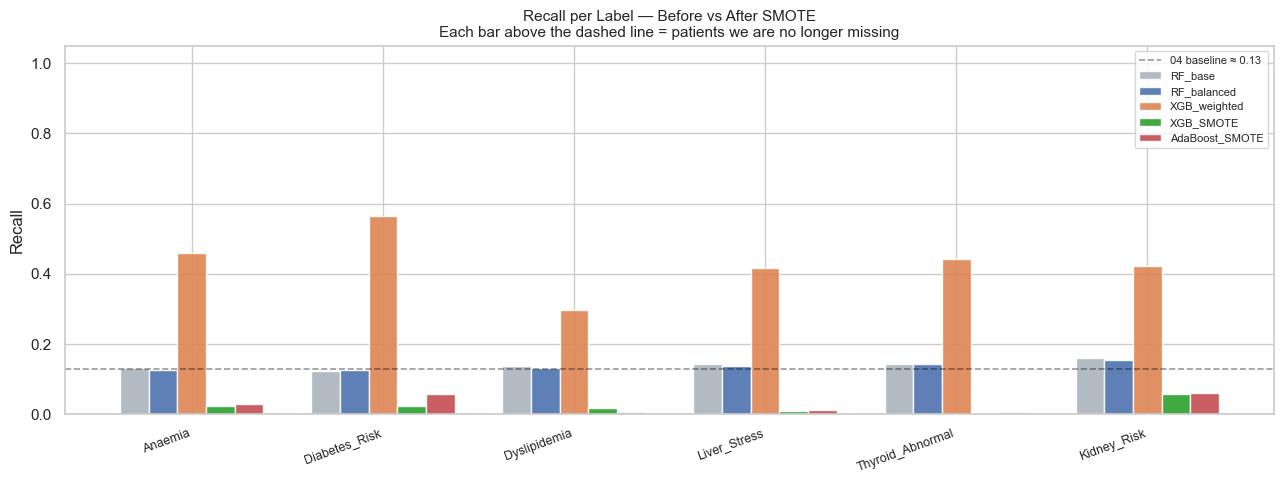

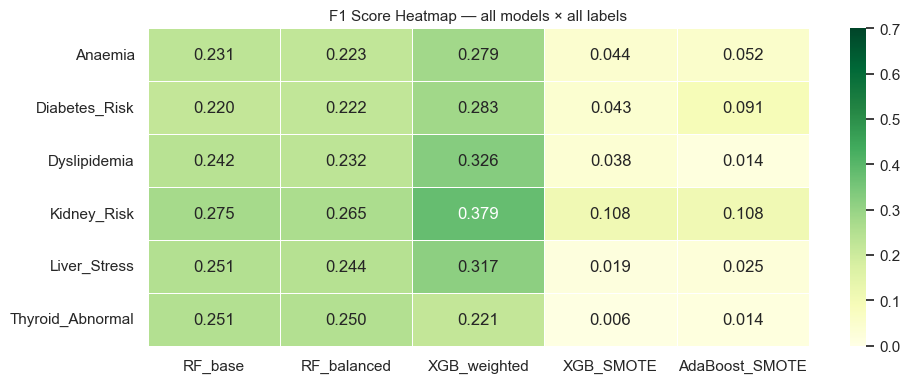

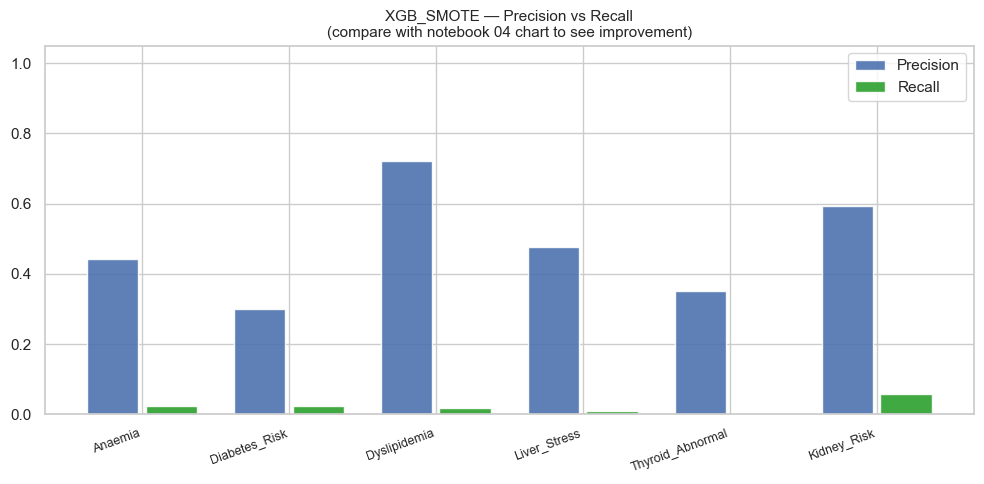

All 3 plots saved to ./results/plots/


In [9]:
MODEL_COLORS = {
    "RF_base":        "#aab4be",
    "RF_balanced":    "#4C72B0",
    "XGB_weighted":   "#DD8452",
    "XGB_SMOTE":      "#2ca02c",
    "AdaBoost_SMOTE": "#C44E52"
}
col_order = ["RF_base", "RF_balanced", "XGB_weighted", "XGB_SMOTE", "AdaBoost_SMOTE"]
x = np.arange(len(LABELS))
w = 0.15

# ── Plot 1: Recall — the headline result ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
for i, model in enumerate(col_order):
    vals = [results_df[(results_df.model==model) &
                       (results_df.label==lbl)]["recall"].values for lbl in LABELS]
    vals = [v[0] if len(v) else 0 for v in vals]
    ax.bar(x + i*w, vals, w, label=model,
           color=MODEL_COLORS[model], alpha=0.9, edgecolor="white")

ax.axhline(0.13, color="black", linestyle="--", linewidth=1.2, alpha=0.4,
           label="04 baseline ≈ 0.13")
ax.set_xticks(x + w*2);  ax.set_xticklabels(LABELS, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("Recall");  ax.set_ylim(0, 1.05)
ax.set_title("Recall per Label — Before vs After SMOTE\n"
             "Each bar above the dashed line = patients we are no longer missing", fontsize=11)
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("./results/plots/05_recall_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 2: F1 heatmap ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
heat = results_df.pivot(index="label", columns="model", values="f1")[col_order].round(3)
sns.heatmap(heat, annot=True, fmt=".3f", cmap="YlGn",
            vmin=0, vmax=0.7, linewidths=0.5, ax=ax)
ax.set_title("F1 Score Heatmap — all models × all labels", fontsize=11)
ax.set_xlabel("");  ax.set_ylabel("")
plt.tight_layout()
plt.savefig("./results/plots/05_f1_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 3: Precision vs Recall for XGB_SMOTE ─────────────────────────────────
xgb_res = results_df[results_df["model"] == "XGB_SMOTE"].set_index("label")
fig, ax = plt.subplots(figsize=(10, 5))
x2 = np.arange(len(LABELS))
ax.bar(x2 - 0.2, xgb_res.loc[LABELS, "precision"], 0.35,
       label="Precision", color="#4C72B0", edgecolor="white", alpha=0.9)
ax.bar(x2 + 0.2, xgb_res.loc[LABELS, "recall"],    0.35,
       label="Recall",    color="#2ca02c", edgecolor="white", alpha=0.9)
ax.set_xticks(x2);  ax.set_xticklabels(LABELS, rotation=20, ha="right", fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_title("XGB_SMOTE — Precision vs Recall\n"
             "(compare with notebook 04 chart to see improvement)", fontsize=11)
ax.legend()
plt.tight_layout()
plt.savefig("./results/plots/05_xgb_precision_recall.png", dpi=150, bbox_inches="tight")
plt.show()

print("All 3 plots saved to ./results/plots/")


## Step 9 — Multi-Label Aggregate Metrics
Uses the predictions already computed in Step 5 — **no retraining needed**.

- **Hamming Loss**: fraction of wrong label-patient pairs (lower = better)
- **Subset Accuracy**: % of patients where ALL 6 labels are correct at once
- **Micro F1**: every label-patient pair weighted equally
- **Macro F1**: each label weighted equally (penalises poor performance on rare labels)


In [10]:
print(f"{'Metric':<25}", end="")
for m in col_order:
    print(f"  {m[:13]:>13}", end="")
print()
print("─" * (25 + 16 * len(col_order)))

metrics = {
    "Hamming Loss ↓":   lambda t, p: hamming_loss(t, p),
    "Subset Accuracy ↑": lambda t, p: (t == p).all(axis=1).mean(),
    "Micro F1 ↑":        lambda t, p: f1_score(t, p, average="micro", zero_division=0),
    "Macro F1 ↑":        lambda t, p: f1_score(t, p, average="macro", zero_division=0),
}

for metric_name, fn in metrics.items():
    print(f"{metric_name:<25}", end="")
    vals = [fn(Y_true_mat, Y_pred_mat[m]) for m in col_order]
    for v in vals:
        print(f"  {v:>13.4f}", end="")
    print()


Metric                           RF_base    RF_balanced   XGB_weighted      XGB_SMOTE  AdaBoost_SMOT
─────────────────────────────────────────────────────────────────────────────────────────────────────────
Hamming Loss ↓                    0.1185         0.1187         0.2600         0.1367         0.1422
Subset Accuracy ↑                 0.5021         0.5020         0.2369         0.4268         0.4149
Micro F1 ↑                        0.2482         0.2417         0.3014         0.0467         0.0494
Macro F1 ↑                        0.2450         0.2396         0.3008         0.0430         0.0507


## Step 10 — Save for Notebook 06

In [11]:
results_df.to_csv("./results/metrics/05_ensemble_results.csv", index=False)
print("Saved: ./results/metrics/05_ensemble_results.csv")

best_per_label = (results_df
    .sort_values("f1", ascending=False)
    .groupby("label").first()
    .reset_index()[["label","model","f1","precision","recall","auc_roc"]])
best_per_label.columns = ["label","best_model","f1","precision","recall","auc_roc"]
best_per_label.to_csv("./results/metrics/05_best_models.csv", index=False)
print("Saved: ./results/metrics/05_best_models.csv")

print()
print("=== Best model per label ===")
print(best_per_label.to_string(index=False))
print()
print("✓ Notebook 05 complete.")
print("  Next → 06_Evaluation.ipynb")


Saved: ./results/metrics/05_ensemble_results.csv
Saved: ./results/metrics/05_best_models.csv

=== Best model per label ===
           label   best_model     f1  precision  recall  auc_roc
         Anaemia XGB_weighted 0.2786     0.1997  0.4605   0.7178
   Diabetes_Risk XGB_weighted 0.2831     0.1889  0.5649   0.7290
    Dyslipidemia XGB_weighted 0.3256     0.3595  0.2976   0.6285
     Kidney_Risk XGB_weighted 0.3786     0.3429  0.4225   0.7015
    Liver_Stress XGB_weighted 0.3174     0.2558  0.4180   0.6456
Thyroid_Abnormal      RF_base 0.2507     0.9734  0.1439   0.6867

✓ Notebook 05 complete.
  Next → 06_Evaluation.ipynb
